In [ ]:
# COMPARISON + VISUALISATION — Defender killings (Global Witness) vs mining conflicts (OCMAL) (Latin America)
#
# Goal: put the two datasets side by side per country and per year, measure how far they agree,
# and save the comparison tables and charts (clean/defenders_vs_conflicts_country.csv, .._year.csv,
# defenders_vs_conflicts.xlsx, figures in figures/).
#
# Project question: Do resource-rich countries in Latin America see more killings of environmental defenders?
#
# Role of this notebook: the conflicts file says WHERE mining is contested; the defenders file says WHERE
# people defending land and environment are killed. If mining drives the killings, countries with many
# mining conflicts should also have many mining-related killings.
# - hypothesis version 1: more mining conflicts -> more killings of defenders (all drivers)
# - hypothesis version 2: more mining conflicts -> more killings linked to "Mining & Extractives"
#
# File — What it contains
# all_latin_america_conflicts_WITH_REGION.csv — 289 rows, one per mining conflict and country (OCMAL titles)
# defenders_cleaned.csv — 2,375 killings/disappearances of land and environmental defenders worldwide, 2012–2025
# americas_df.csv — the 1,725 Americas rows of defenders_cleaned.csv + victim type and perpetrator columns
#
# Source: Global Witness land and environmental defenders data (2012–2025) ⚠ team to add access date;
# OCMAL conflict database ⚠ team to confirm source and access date (see status_mining_conflicts.md).
#
# Know before using it:
# - The two files count different things: a conflict is a dispute that started once (1972–2019);
#   a killing is one person on one date (2012–2025). Only 2012–2019 overlaps in time.
# - Global Witness counts only cases it could verify; under-reporting is strong where the press is weak.
# - OCMAL has no rows after 2019 and no end dates, so a conflict count is a stock of disputes, not activity per year.
# - "industry_driver" is one label per case; a killing tied to land and mining may be filed under "Land".
#
# Units: one row in a table here = one country (or one year); numbers are counts of rows.
#
# Every decision is recorded in log and exported at the end, as in the other notebooks.

In [ ]:
# 1) Setup
# What: libraries, paths, the team colours.
# Why: colours are fixed per measure so every chart reads the same way:
# - blue = mining conflicts (OCMAL)
# - orange = killings linked to Mining & Extractives (Global Witness)
# - grey = all other killings (Global Witness)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#b5b3ad"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
})
os.makedirs("clean", exist_ok=True)
os.makedirs("figures", exist_ok=True)
log = []
print("ready")

ready


In [ ]:
# 2) Load
# What: read the three files from this folder, else from the team GitHub.
# ⚠ The GitHub paths assume the files sit at the root of the main branch — fix if they moved.
# Output: shape of each file.

In [2]:
GITHUB = "https://raw.githubusercontent.com/len-chou/TeamTokio---Week-3-Project-/main/"

def load(name):
    for path in [name, os.path.join("data", name), os.path.join("/mnt/user-data/uploads", name)]:
        if os.path.exists(path):
            return pd.read_csv(path)
    try:
        return pd.read_csv(GITHUB + name)
    except Exception as e:
        raise FileNotFoundError(
            f"{name} not found. Put it in the same folder as this notebook (or in data/), "
            f"or fix the GITHUB path above. GitHub error: {e}") from None

conflicts_raw = load("all_latin_america_conflicts_WITH_REGION.csv")
defenders_raw = load("defenders_cleaned.csv")
americas_raw = load("americas_df.csv")
for n, d in [("conflicts", conflicts_raw), ("defenders", defenders_raw), ("americas", americas_raw)]:
    print(f"{n:10s} {d.shape[0]:>5} rows x {d.shape[1]} columns")

conflicts    289 rows x 5 columns
defenders   2375 rows x 9 columns
americas    1725 rows x 11 columns


In [ ]:
# 3) Make the two files talk to each other
# 3A. Check that americas_df is the Americas part of defenders_cleaned
# Why: if they match we can use americas_df (it has victim type and perpetrator) without losing cases.
# Output: True if the case ids are identical.

In [3]:
same_ids = set(americas_raw["id"]) == set(defenders_raw.loc[defenders_raw["event_continent"] == "Americas", "id"])
print("americas_df = Americas rows of defenders_cleaned:", same_ids)
log.append(("americas_df", "checked same ids as defenders_cleaned (Americas)", str(same_ids)))

americas_df = Americas rows of defenders_cleaned: True


In [ ]:
# 3B. Same country names in both files
# Problem: OCMAL uses Spanish names (México, Perú, Brasil…), Global Witness uses English names.
# How: one dictionary Spanish -> English. Canada and USA are dropped from Global Witness (not Latin America).
# Output: countries present in each file and in both.

In [4]:
ES_TO_EN = {"México": "Mexico", "Perú": "Peru", "Brasil": "Brazil", "Panamá": "Panama",
            "República Dominicana": "Dominican Republic", "Guayana Francesa": "French Guiana",
            "Trinidad y Tobago": "Trinidad and Tobago"}
conflicts = conflicts_raw.copy()
conflicts["country"] = conflicts["pais"].replace(ES_TO_EN)
conflicts["start_year"] = conflicts["inicio_conflicto"].astype("Int64")

killings = americas_raw[~americas_raw["event_country"].isin(["United States of America", "Canada"])].copy()
killings = killings.rename(columns={"event_country": "country"})
killings["mining"] = killings["industry_driver"].eq("Mining & Extractives")
log.append(("conflicts", "Spanish country names -> English", f"{len(ES_TO_EN)} names"))
log.append(("killings", "dropped USA and Canada", f"{len(americas_raw) - len(killings)} rows"))

c_set, k_set = set(conflicts["country"]), set(killings["country"])
print("only in conflicts:", sorted(c_set - k_set))
print("only in killings :", sorted(k_set - c_set))
print("in both          :", len(c_set & k_set), "countries")

only in conflicts: ['El Salvador', 'French Guiana', 'Trinidad and Tobago', 'Uruguay']
only in killings : []
in both          : 16 countries


In [ ]:
# 4) Country table
# What: per country — mining conflicts, all killings, mining killings, share of killings that are mining-related,
#       and the same counts limited to the overlap years 2012–2019.
# Why: the core comparison. Countries missing from one file get 0 ⚠ (0 can mean "not covered", not "none").
# Output: the table sorted by mining conflicts.

In [5]:
conf_n = conflicts.groupby("country").size().rename("mining_conflicts")
conf_recent = conflicts[conflicts["start_year"].ge(2005).fillna(False).astype(bool)].groupby("country").size().rename("conflicts_started_2005_2019")
kill_all = killings.groupby("country").size().rename("killings_all")
kill_min = killings[killings["mining"]].groupby("country").size().rename("killings_mining")
ov = killings[killings["year"].between(2012, 2019)]
kill_all_ov = ov.groupby("country").size().rename("killings_all_2012_2019")
kill_min_ov = ov[ov["mining"]].groupby("country").size().rename("killings_mining_2012_2019")

country = (pd.concat([conf_n, conf_recent, kill_all, kill_min, kill_all_ov, kill_min_ov], axis=1)
           .fillna(0).astype(int))
country["mining_share_of_killings_pct"] = (100 * country["killings_mining"] / country["killings_all"].replace(0, np.nan)).round(1)
country["share_of_latam_conflicts_pct"] = (100 * country["mining_conflicts"] / country["mining_conflicts"].sum()).round(1)
country["share_of_latam_mining_killings_pct"] = (100 * country["killings_mining"] / country["killings_mining"].sum()).round(1)
country = country.sort_values(["mining_conflicts", "killings_all"], ascending=False)
country.index.name = "country"
country

,mining_conflicts,conflicts_started_2005_2019,killings_all,killings_mining,killings_all_2012_2019,killings_mining_2012_2019,mining_share_of_killings_pct,share_of_latam_conflicts_pct,share_of_latam_mining_killings_pct
country,,,,,,,,,
Mexico,58,43,230,42,70,11,18.3,20.1,21.0
Chile,49,33,5,0,3,0,0.0,17.0,0.0
Peru,46,28,66,32,38,26,48.5,15.9,16.0
Argentina,28,17,8,0,5,0,0.0,9.7,0.0
Brazil,26,15,439,17,296,10,3.9,9.0,8.5
Colombia,19,14,548,47,224,37,8.6,6.6,23.5
Guatemala,10,8,114,19,63,14,16.7,3.5,9.5
Bolivia,10,4,2,0,1,0,0.0,3.5,0.0
Ecuador,9,7,12,5,1,1,41.7,3.1,2.5


In [ ]:
# 5) Do the two measures move together?
# What: Spearman rank correlation across countries (ranks, because a few countries are very large).
# Why: answers the two hypothesis versions with one number each.
# How: all 23 countries, then only countries present in BOTH files (zeros removed), as a check.
# Output: rho and p-value for each pair.

In [6]:
def rho(df, a, b):
    r, p = spearmanr(df[a], df[b])
    return round(r, 2), round(p, 3), len(df)

both = country[(country["mining_conflicts"] > 0) & (country["killings_all"] > 0)]
tests = pd.DataFrame([
    ("conflicts vs all killings", "all countries", *rho(country, "mining_conflicts", "killings_all")),
    ("conflicts vs mining killings", "all countries", *rho(country, "mining_conflicts", "killings_mining")),
    ("conflicts vs all killings", "in both files", *rho(both, "mining_conflicts", "killings_all")),
    ("conflicts vs mining killings", "in both files", *rho(both, "mining_conflicts", "killings_mining")),
    ("conflicts vs mining killings 2012–2019", "all countries", *rho(country, "mining_conflicts", "killings_mining_2012_2019")),
], columns=["pair", "countries", "spearman_rho", "p_value", "n"])
tests

,pair,countries,spearman_rho,p_value,n
0,conflicts vs all killings,all countries,0.58,0.007,20
1,conflicts vs mining killings,all countries,0.52,0.019,20
2,conflicts vs all killings,in both files,0.30,0.260,16
3,conflicts vs mining killings,in both files,0.35,0.188,16
4,conflicts vs mining killings 2012–2019,all countries,0.50,0.024,20


In [ ]:
# 6) Where the two lists disagree most
# What: difference between a country's share of LatAm mining conflicts and its share of LatAm mining killings.
# Why: positive = many conflicts but few killings (conflict without lethal violence);
#      negative = few conflicts recorded but many killings (violence the conflict map misses).
# Output: the gap per country, largest first.

In [7]:
gap = (country["share_of_latam_conflicts_pct"] - country["share_of_latam_mining_killings_pct"]).rename("gap_pts")
gap_tbl = country[["share_of_latam_conflicts_pct", "share_of_latam_mining_killings_pct"]].join(gap)
gap_tbl = gap_tbl[(country["mining_conflicts"] > 0) | (country["killings_mining"] > 0)].sort_values("gap_pts")
gap_tbl

,share_of_latam_conflicts_pct,share_of_latam_mining_killings_pct,gap_pts
country,,,
Colombia,6.6,23.5,-16.9
Venezuela,0.7,8.0,-7.3
Guatemala,3.5,9.5,-6.0
Honduras,2.1,5.0,-2.9
Mexico,20.1,21.0,-0.9
Nicaragua,2.4,3.0,-0.6
Peru,15.9,16.0,-0.1
Dominican Republic,1.0,1.0,0.0
Uruguay,0.3,0.0,0.3


In [ ]:
# 7) Year table
# What: conflicts that started each year (OCMAL) next to killings each year (Global Witness).
# Why: shows how little the two time windows overlap (2012–2019 only).
# Output: last rows of the table.

In [8]:
year = pd.concat([
    conflicts.dropna(subset=["start_year"]).groupby("start_year").size().rename("conflicts_started"),
    killings.groupby("year").size().rename("killings_all"),
    killings[killings["mining"]].groupby("year").size().rename("killings_mining"),
], axis=1).fillna(0).astype(int)
year.index = year.index.astype(int)
year = year.reindex(range(year.index.min(), year.index.max() + 1), fill_value=0)
year.index.name = "year"
print("conflicts with no start year:", conflicts["start_year"].isna().sum())
year.tail(16)

conflicts with no start year: 30


,conflicts_started,killings_all,killings_mining
year,,,
2010,18,0,0
2011,11,0,0
2012,12,108,20
2013,10,73,12
2014,8,88,12
2015,10,120,21
2016,8,119,13
2017,5,116,8
2018,5,83,9


In [ ]:
# 8) Charts
# 8A. Scatter — mining conflicts vs mining-related killings, one dot per country
# Why: the most direct picture of hypothesis 2. Dots far from the diagonal are the interesting countries.
# Output: figures/01_scatter_conflicts_vs_mining_killings.png

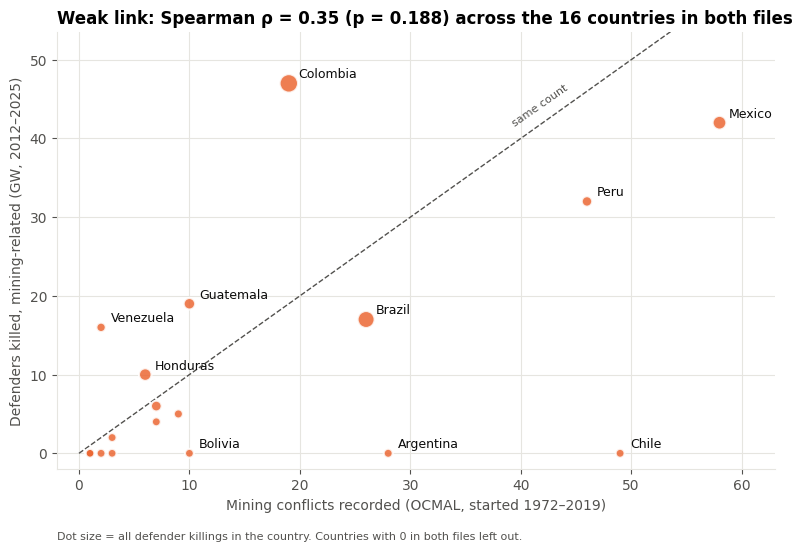

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.6))
d = country[(country["mining_conflicts"] > 0) | (country["killings_mining"] > 0)]
ax.scatter(d["mining_conflicts"], d["killings_mining"], s=40 + d["killings_all"] / 4,
           color=ORANGE, alpha=0.85, edgecolor="white", linewidth=1.5, zorder=3)
for name, r in d.iterrows():
    if r["mining_conflicts"] >= 10 or r["killings_mining"] >= 10:
        ax.annotate(name, (r["mining_conflicts"], r["killings_mining"]), xytext=(7, 4),
                    textcoords="offset points", fontsize=9, color=INK)
lim = max(d["mining_conflicts"].max(), d["killings_mining"].max()) + 5
ax.plot([0, lim], [0, lim], color=INK2, lw=1, ls="--", zorder=1)
ax.text(lim * 0.62, lim * 0.66, "same count", color=INK2, fontsize=8, rotation=35)
ax.set_xlim(-2, lim); ax.set_ylim(-2, lim * 0.85)
ax.set_xlabel("Mining conflicts recorded (OCMAL, started 1972–2019)")
ax.set_ylabel("Defenders killed, mining-related (GW, 2012–2025)")
r_, p_, n_ = rho(both, "mining_conflicts", "killings_mining")
ax.set_title(f"Weak link: Spearman ρ = {r_} (p = {p_}) across the {n_} countries in both files")
ax.text(0, -0.16, "Dot size = all defender killings in the country. Countries with 0 in both files left out.",
        transform=ax.transAxes, fontsize=8, color=INK2)
fig.tight_layout(); fig.savefig("figures/01_scatter_conflicts_vs_mining_killings.png", bbox_inches="tight")
plt.show()

In [ ]:
# 8B. Side-by-side bars per country — conflicts | mining killings | all killings
# Why: same countries, three counts, read across one row. Separate panels, so no shared or double axis.
# Output: figures/02_country_bars.png

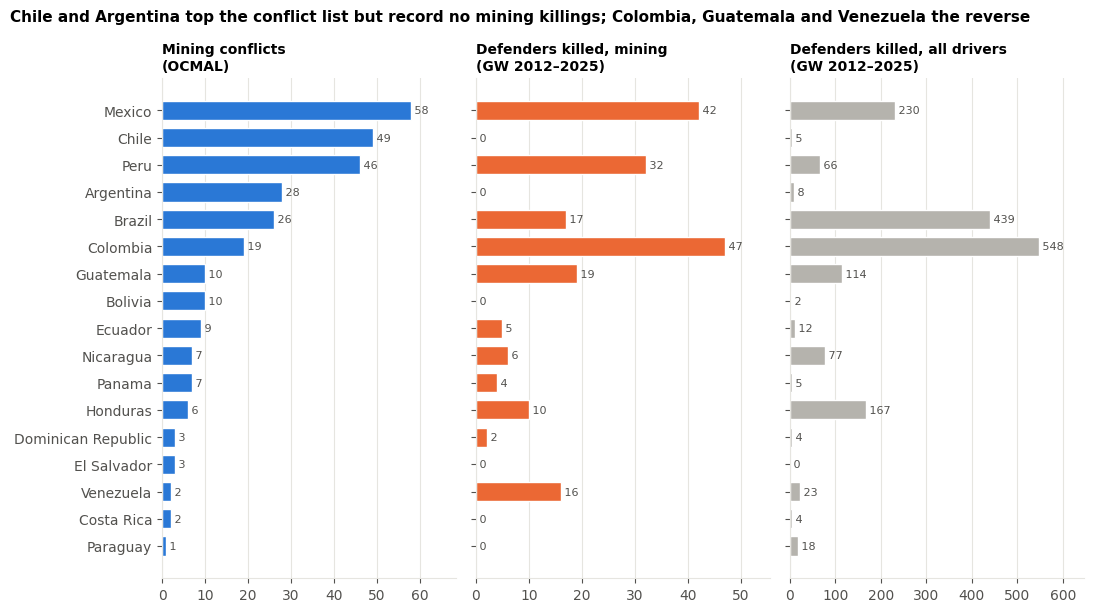

In [10]:
d = country[(country["mining_conflicts"] >= 2) | (country["killings_all"] >= 10)]
d = d.sort_values("mining_conflicts")
fig, axes = plt.subplots(1, 3, figsize=(11, 6.2), sharey=True)
panels = [("mining_conflicts", "Mining conflicts\n(OCMAL)", BLUE),
          ("killings_mining", "Defenders killed, mining\n(GW 2012–2025)", ORANGE),
          ("killings_all", "Defenders killed, all drivers\n(GW 2012–2025)", GREY)]
for ax, (col, title, colr) in zip(axes, panels):
    ax.barh(d.index, d[col], color=colr, height=0.7, edgecolor="white", linewidth=1)
    for y, v in enumerate(d[col]):
        ax.text(v, y, f" {v}", va="center", fontsize=8, color=INK2)
    ax.set_title(title, fontsize=10, loc="left")
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, d[col].max() * 1.18)
fig.suptitle("Chile and Argentina top the conflict list but record no mining killings; Colombia, Guatemala and Venezuela the reverse",
             x=0.01, ha="left", fontweight="bold", fontsize=11)
fig.tight_layout(); fig.savefig("figures/02_country_bars.png", bbox_inches="tight")
plt.show()

In [ ]:
# 8C. Gap chart — share of LatAm conflicts minus share of LatAm mining killings
# Why: one bar per country shows which data source "over-" or "under-" represents it.
# Output: figures/03_share_gap.png

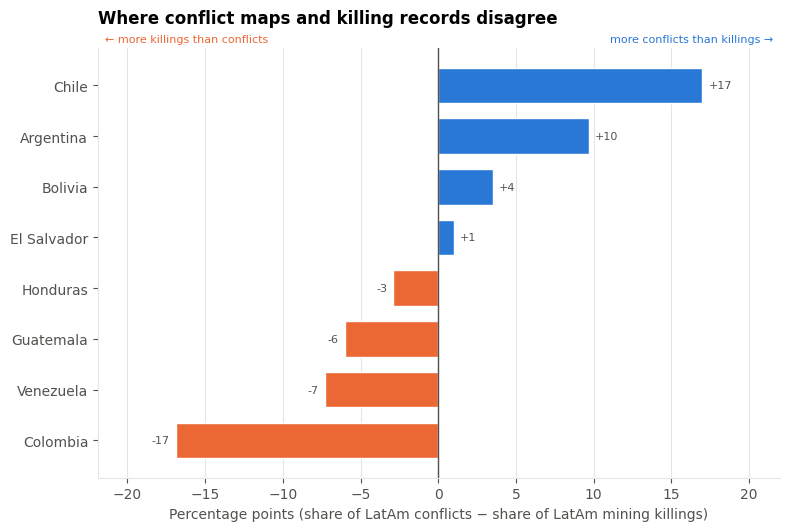

In [11]:
g = gap_tbl[gap_tbl["gap_pts"].abs() >= 1]
fig, ax = plt.subplots(figsize=(8, 5.4))
cols = [BLUE if v > 0 else ORANGE for v in g["gap_pts"]]
ax.barh(g.index, g["gap_pts"], color=cols, height=0.7, edgecolor="white", linewidth=1)
for y, v in enumerate(g["gap_pts"]):
    ax.text(v + (0.4 if v > 0 else -0.4), y, f"{v:+.0f}", va="center",
            ha="left" if v > 0 else "right", fontsize=8, color=INK2)
ax.axvline(0, color=INK2, lw=1)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Percentage points (share of LatAm conflicts − share of LatAm mining killings)")
ax.set_title("Where conflict maps and killing records disagree")
lo, hi = g["gap_pts"].min(), g["gap_pts"].max()
ax.set_xlim(lo - 5, hi + 5)
ax.text(0.99, 1.01, "more conflicts than killings →", transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color=BLUE)
ax.text(0.01, 1.01, "← more killings than conflicts", transform=ax.transAxes, ha="left", va="bottom", fontsize=8, color=ORANGE)
ax.set_title("Where conflict maps and killing records disagree", pad=18)
fig.tight_layout(); fig.savefig("figures/03_share_gap.png", bbox_inches="tight")
plt.show()

In [ ]:
# 8D. Time — conflicts started per year (top) and killings per year (bottom), shared year axis
# Why: shows the overlap window 2012–2019 and that the two series cannot be compared year by year
#      outside it. Two panels, not a double axis.
# Output: figures/04_timeline.png

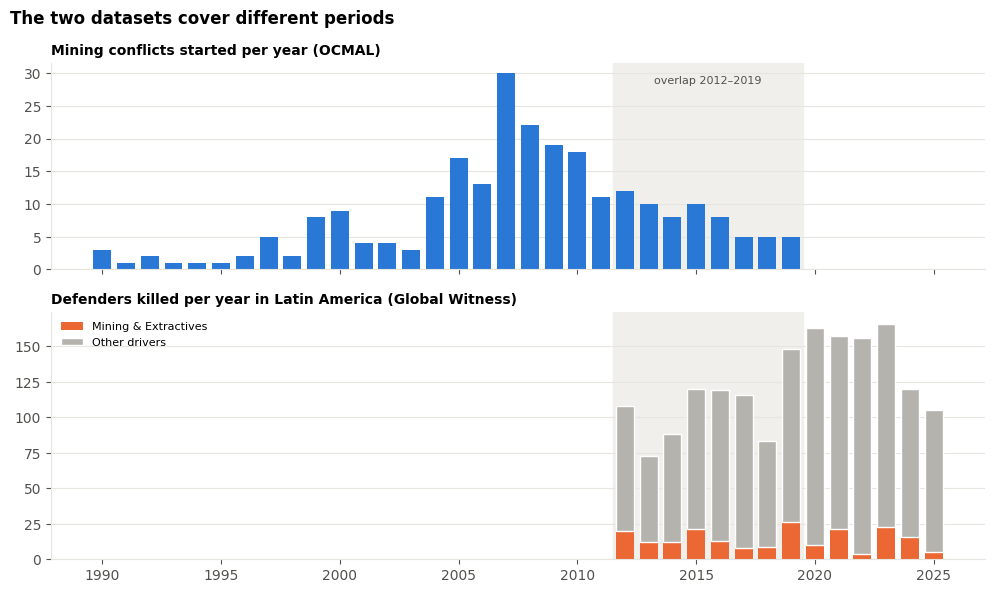

In [12]:
y = year.loc[1990:]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [1, 1.2]})
a1.bar(y.index, y["conflicts_started"], color=BLUE, width=0.75)
a1.set_title("Mining conflicts started per year (OCMAL)", fontsize=10)
other = y["killings_all"] - y["killings_mining"]
a2.bar(y.index, y["killings_mining"], color=ORANGE, width=0.75, label="Mining & Extractives")
a2.bar(y.index, other, bottom=y["killings_mining"], color=GREY, width=0.75,
       edgecolor="white", linewidth=1, label="Other drivers")
a2.set_title("Defenders killed per year in Latin America (Global Witness)", fontsize=10)
a2.legend(frameon=False, loc="upper left", fontsize=8)
for ax in (a1, a2):
    ax.axvspan(2011.5, 2019.5, color="#f0efec", zorder=0)
    ax.grid(axis="x", visible=False)
a1.text(2015.5, a1.get_ylim()[1] * 0.9, "overlap 2012–2019", ha="center", fontsize=8, color=INK2)
fig.suptitle("The two datasets cover different periods", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig("figures/04_timeline.png", bbox_inches="tight")
plt.show()

In [ ]:
# 8E. Who is killed and by whom — mining cases vs all other cases (Latin America)
# Why: tells us whether mining violence has its own profile (victims, perpetrators).
# How: share of cases in each group; categories under 3 % folded into "Other". Unknown kept, it is large.
# Output: figures/05_victims_perpetrators.png

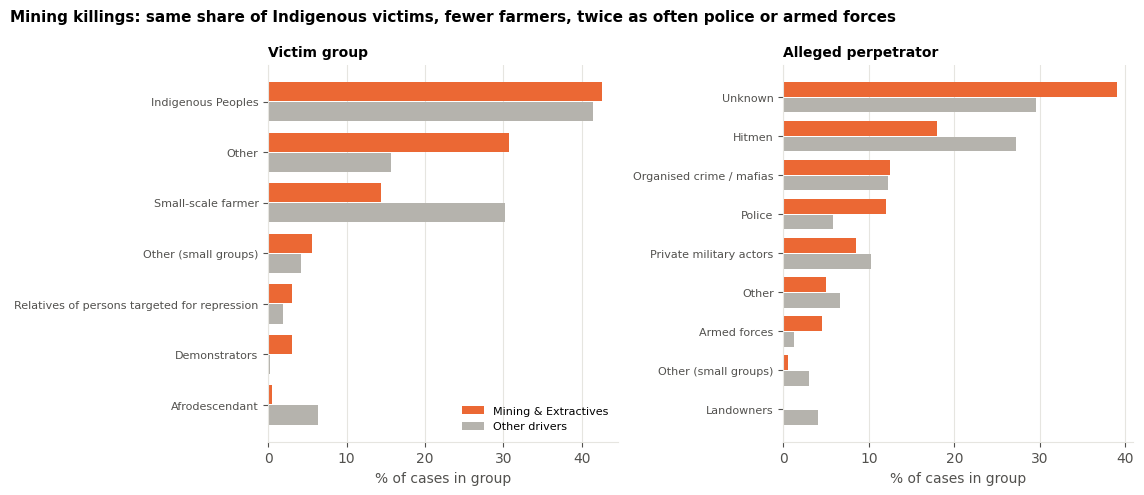

In [13]:
def shares(col):
    t = (killings.assign(group=np.where(killings["mining"], "Mining", "Other drivers"))
         .groupby("group")[col].value_counts(normalize=True).mul(100).unstack(0).fillna(0))
    small = t.max(axis=1) < 3
    folded = t[~small].copy()
    folded.loc["Other (small groups)"] = t[small].sum()
    return folded.sort_values("Mining")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5))
for ax, col, title in [(axes[0], "person_characteristics", "Victim group"),
                       (axes[1], "involvement_perpetrator_type", "Alleged perpetrator")]:
    t = shares(col)
    pos = np.arange(len(t))
    ax.barh(pos + 0.2, t["Mining"], height=0.38, color=ORANGE, label="Mining & Extractives")
    ax.barh(pos - 0.2, t["Other drivers"], height=0.38, color=GREY, label="Other drivers")
    ax.set_yticks(pos, t.index, fontsize=8)
    ax.set_xlabel("% of cases in group")
    ax.set_title(title, fontsize=10); ax.grid(axis="y", visible=False)
axes[0].legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle("Mining killings: same share of Indigenous victims, fewer farmers, twice as often police or armed forces",
             x=0.01, ha="left", fontweight="bold", fontsize=11)
fig.tight_layout(); fig.savefig("figures/05_victims_perpetrators.png", bbox_inches="tight")
plt.show()

In [ ]:
# 9) Checks
# Output: table of checks with passed = True/False.

In [14]:
checks = pd.DataFrame([
    ("americas_df ids = Americas ids in defenders_cleaned", same_ids),
    ("country table conflicts sum = conflict rows", country["mining_conflicts"].sum() == len(conflicts)),
    ("country table killings sum = LatAm killing rows", country["killings_all"].sum() == len(killings)),
    ("mining killings <= all killings in every country", (country["killings_mining"] <= country["killings_all"]).all()),
    ("year table killings sum = LatAm killing rows", year["killings_all"].sum() == len(killings)),
    ("all 5 figures saved", len([f for f in os.listdir("figures") if f.endswith(".png")]) >= 5),
], columns=["check", "passed"])
checks

,check,passed
0,americas_df ids = Americas ids in defenders_cleaned,True
1,country table conflicts sum = conflict rows,True
2,country table killings sum = LatAm killing rows,True
3,mining killings <= all killings in every country,True
4,year table killings sum = LatAm killing rows,True
5,all 5 figures saved,True


In [ ]:
# 10) Export
# What: country table, year table, correlation tests, gap table and log as CSV + one Excel workbook.
# Output: list of files written.

In [15]:
log_df = pd.DataFrame(log, columns=["table", "decision", "detail"])
out = {"defenders_vs_conflicts_country": country.reset_index(),
       "defenders_vs_conflicts_year": year.reset_index(),
       "defenders_vs_conflicts_tests": tests,
       "defenders_vs_conflicts_gap": gap_tbl.reset_index(),
       "defenders_vs_conflicts_log": log_df}
for name, df in out.items():
    df.to_csv(f"clean/{name}.csv", index=False)
with pd.ExcelWriter("clean/defenders_vs_conflicts.xlsx") as xw:
    for name, df in out.items():
        df.to_excel(xw, sheet_name=name.replace("defenders_vs_conflicts_", ""), index=False)
print("\n".join(sorted(os.listdir("clean"))))

defenders_vs_conflicts.xlsx
defenders_vs_conflicts_country.csv
defenders_vs_conflicts_gap.csv
defenders_vs_conflicts_log.csv
defenders_vs_conflicts_tests.csv
defenders_vs_conflicts_year.csv


In [ ]:
# 11) What this comparison can and cannot show
# - Can show: the countries where mining is most contested (Mexico, Chile, Peru, Argentina) are NOT the same as
#   the countries where defenders tied to mining are killed most (Colombia, Mexico, Peru, Guatemala).
#   Mexico and Peru are high on both lists; Chile and Argentina have many conflicts and no recorded mining killings;
#   Colombia, Honduras, Guatemala and Venezuela have more mining killings than their conflict count suggests.
# - Can show: in mining cases the victim is Indigenous as often as in other cases (about 42 %), but the alleged
#   perpetrator is more often police (12 % vs 6 %) or armed forces (4 % vs 1 %), and more often unknown (39 % vs 30 %).
# - Can show: mining killings are a minority (about 12 %) of all defender killings in Latin America; land is the main driver.
# - Cannot show cause: rank correlations across ~20 countries are weak evidence, and both datasets under-record.
# - Cannot compare per year beyond 2012–2019, and a conflict "start year" is not a year of activity.
# - Cannot adjust for population or mining output here — next step: join country_resource_profile.csv
#   (resource richness) and population to get killings per million people and per unit of production.
# ⚠ OCMAL coverage may be uneven (strong in Chile/Mexico/Peru networks, weaker in Colombia/Honduras);
#   part of the gap may be about who records conflicts, not where they happen.